# Regression Project

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,MinMaxScaler,OrdinalEncoder,PolynomialFeatures
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error,mean_absolute_error,root_mean_squared_error,accuracy_score,r2_score
import joblib

In [4]:
df = pd.read_csv("/content/drive/MyDrive/ML Project/eco-friendly-product-dataset.csv")
df.head()

,Unnamed: 0,week_start,region,avg_temp,google_trend_score,marketing_spend,store_visits,holiday_flag,sales,quarter
0,0,02-01-2022,North,16.148359,77.731496,59.477217,171.287943,0,524.698094,2022Q1
1,1,09-01-2022,North,13.498203,56.721545,42.961597,129.713810,0,478.079702,2022Q1
2,2,16-01-2022,North,20.155553,63.583106,41.756808,138.380782,1,506.284918,2022Q1
3,3,23-01-2022,North,18.852930,47.855055,83.285668,140.217833,1,512.270721,2022Q1
4,4,30-01-2022,North,16.324140,98.691569,14.112839,168.959707,0,517.403233,2022Q1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 628 entries, 0 to 627
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          628 non-null    int64  
 1   week_start          628 non-null    object 
 2   region              628 non-null    object 
 3   avg_temp            628 non-null    float64
 4   google_trend_score  628 non-null    float64
 5   marketing_spend     628 non-null    float64
 6   store_visits        628 non-null    float64
 7   holiday_flag        628 non-null    int64  
 8   sales               628 non-null    float64
 9   quarter             628 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 49.2+ KB


In [6]:
df = df.drop(axis=1,columns="Unnamed: 0")
df.head()

,week_start,region,avg_temp,google_trend_score,marketing_spend,store_visits,holiday_flag,sales,quarter
0,02-01-2022,North,16.148359,77.731496,59.477217,171.287943,0,524.698094,2022Q1
1,09-01-2022,North,13.498203,56.721545,42.961597,129.713810,0,478.079702,2022Q1
2,16-01-2022,North,20.155553,63.583106,41.756808,138.380782,1,506.284918,2022Q1
3,23-01-2022,North,18.852930,47.855055,83.285668,140.217833,1,512.270721,2022Q1
4,30-01-2022,North,16.324140,98.691569,14.112839,168.959707,0,517.403233,2022Q1


In [7]:
df.isna().sum()

,0
week_start,0
region,0
avg_temp,0
google_trend_score,0
marketing_spend,0
store_visits,0
holiday_flag,0
sales,0
quarter,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,avg_temp,google_trend_score,marketing_spend,store_visits,holiday_flag,sales
count,628.000000,628.000000,628.000000,628.000000,628.000000,628.000000
mean,24.986046,71.788369,50.601523,146.670486,0.181529,531.869402
std,8.120082,14.660826,21.721709,17.728933,0.385763,60.638006
min,-3.707696,20.000000,-11.654688,100.320913,0.000000,423.263286
25%,19.558428,61.802410,35.745655,133.672368,0.000000,487.488359
50%,25.770820,72.039636,51.292144,146.309609,0.000000,515.715335
75%,31.166459,81.646194,64.860207,159.443478,0.000000,579.248010
max,44.825052,100.000000,116.255308,202.855078,1.000000,702.612738


In [10]:
df['week_start'] = pd.to_datetime(df['week_start'],dayfirst=True)
df.head()

,week_start,region,avg_temp,google_trend_score,marketing_spend,store_visits,holiday_flag,sales,quarter
0,2022-01-02,North,16.148359,77.731496,59.477217,171.287943,0,524.698094,2022Q1
1,2022-01-09,North,13.498203,56.721545,42.961597,129.713810,0,478.079702,2022Q1
2,2022-01-16,North,20.155553,63.583106,41.756808,138.380782,1,506.284918,2022Q1
3,2022-01-23,North,18.852930,47.855055,83.285668,140.217833,1,512.270721,2022Q1
4,2022-01-30,North,16.324140,98.691569,14.112839,168.959707,0,517.403233,2022Q1


In [11]:
df.isna().sum()

,0
week_start,0
region,0
avg_temp,0
google_trend_score,0
marketing_spend,0
store_visits,0
holiday_flag,0
sales,0
quarter,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 628 entries, 0 to 627
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   week_start          628 non-null    datetime64[ns]
 1   region              628 non-null    object        
 2   avg_temp            628 non-null    float64       
 3   google_trend_score  628 non-null    float64       
 4   marketing_spend     628 non-null    float64       
 5   store_visits        628 non-null    float64       
 6   holiday_flag        628 non-null    int64         
 7   sales               628 non-null    float64       
 8   quarter             628 non-null    object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(2)
memory usage: 44.3+ KB


In [13]:
df['year'] = df['week_start'].dt.year

In [14]:
df['quarter'] = "Q"+df['week_start'].dt.quarter.astype(str)

In [15]:
df['month'] = df['week_start'].dt.month_name()

In [16]:
df.head()

,week_start,region,avg_temp,google_trend_score,marketing_spend,store_visits,holiday_flag,sales,quarter,year,month
0,2022-01-02,North,16.148359,77.731496,59.477217,171.287943,0,524.698094,Q1,2022,January
1,2022-01-09,North,13.498203,56.721545,42.961597,129.713810,0,478.079702,Q1,2022,January
2,2022-01-16,North,20.155553,63.583106,41.756808,138.380782,1,506.284918,Q1,2022,January
3,2022-01-23,North,18.852930,47.855055,83.285668,140.217833,1,512.270721,Q1,2022,January
4,2022-01-30,North,16.324140,98.691569,14.112839,168.959707,0,517.403233,Q1,2022,January


# Outlier Detection

In [17]:
numeric_col = df.select_dtypes(include=float).columns
numeric_col

Index(['avg_temp', 'google_trend_score', 'marketing_spend', 'store_visits',
       'sales'],
      dtype='object')

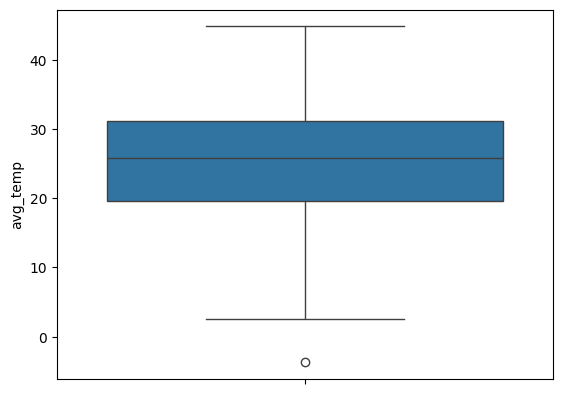

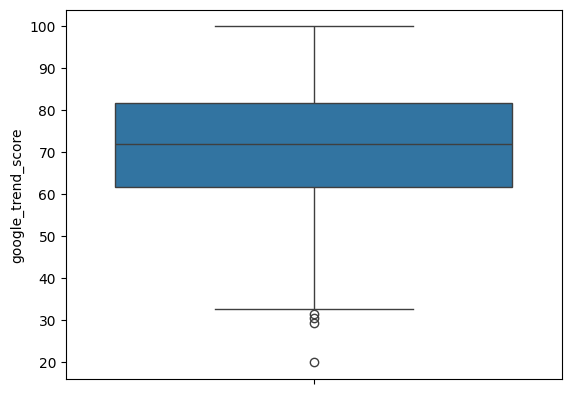

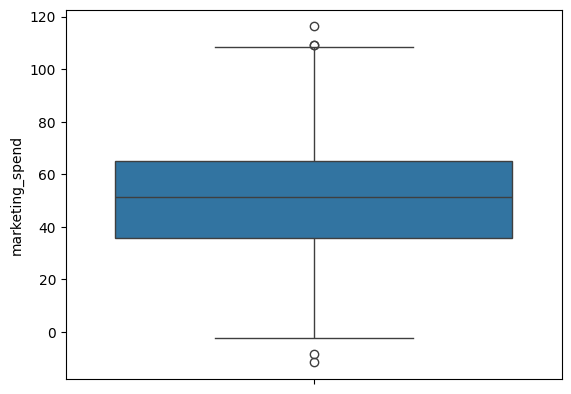

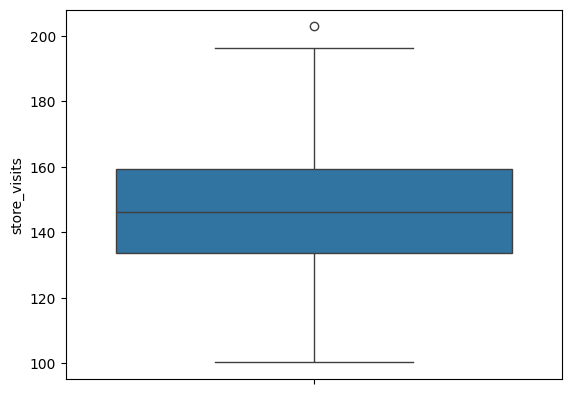

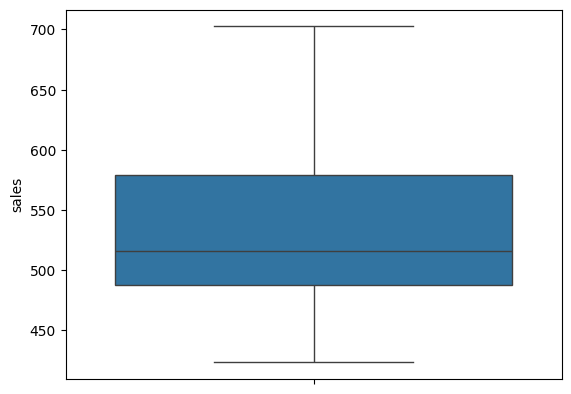

In [18]:
for col in numeric_col:
  sns.boxplot(df[col])
  plt.show()

In [19]:
df_copy = df.copy()
df_copy.head()

,week_start,region,avg_temp,google_trend_score,marketing_spend,store_visits,holiday_flag,sales,quarter,year,month
0,2022-01-02,North,16.148359,77.731496,59.477217,171.287943,0,524.698094,Q1,2022,January
1,2022-01-09,North,13.498203,56.721545,42.961597,129.713810,0,478.079702,Q1,2022,January
2,2022-01-16,North,20.155553,63.583106,41.756808,138.380782,1,506.284918,Q1,2022,January
3,2022-01-23,North,18.852930,47.855055,83.285668,140.217833,1,512.270721,Q1,2022,January
4,2022-01-30,North,16.324140,98.691569,14.112839,168.959707,0,517.403233,Q1,2022,January


In [20]:
for col in numeric_col:
  Q1 = df_copy[col].quantile(0.25)
  Q3 = df_copy[col].quantile(0.75)

  IQR = Q3 - Q1

  upperlimit = Q3 + (1.5 * IQR)
  lowerlimit = Q1 - (1.5 * IQR)

  df_copy = df_copy[ (df_copy[col] < upperlimit) & (df_copy[col] > lowerlimit)]

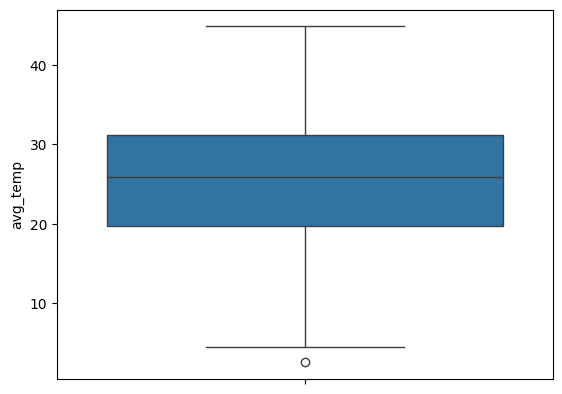

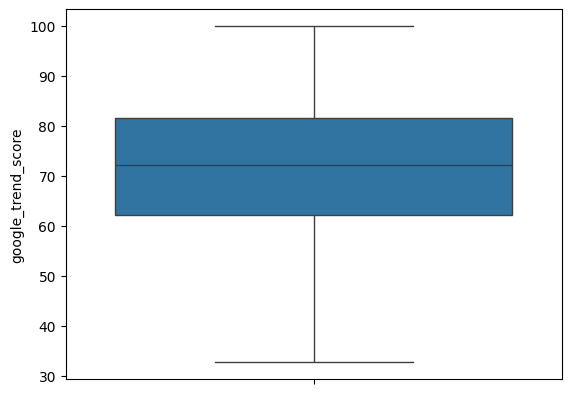

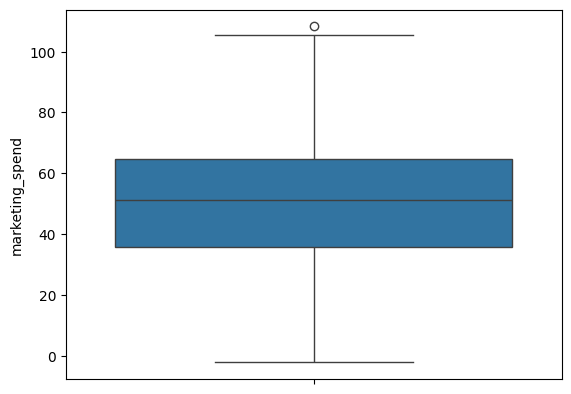

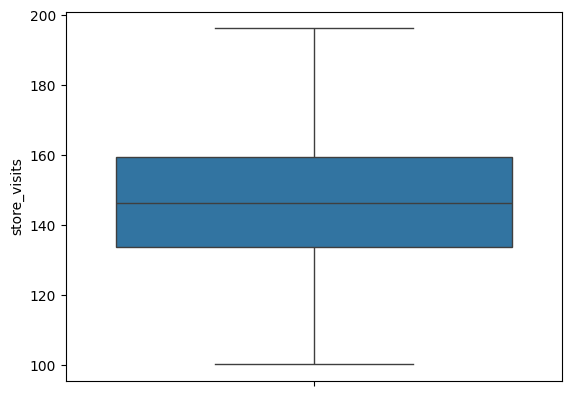

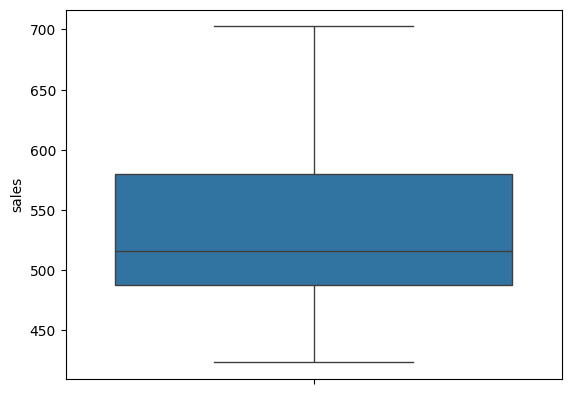

In [21]:
for col in numeric_col:
  sns.boxplot(df_copy[col])
  plt.show()

# EDA

In [22]:
t=df_copy.groupby('year')['sales'].sum().reset_index()
t

,year,sales
0,2022,109147.598265
1,2023,111307.300632
2,2024,107995.654366


In [23]:
fig = px.bar(t, x='year', y='sales', title='Total Sales by Year',text_auto=True)
fig.update_xaxes(dtick=1)
fig.show()

In [24]:
t=df_copy.groupby('region')['sales'].sum().reset_index()
t

,region,sales
0,East,77918.996385
1,North,78923.332046
2,South,96493.289503
3,West,75114.935328


In [25]:
fig = px.pie(t, names='region', values='sales', hole=0.4)
fig.show()

In [26]:
t = df_copy.groupby(["year","month"])['sales'].sum().reset_index()

In [27]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

t['month'] = pd.Categorical(
    t['month'],
    categories=month_order,
    ordered=True
)

t = t.sort_values(['year', 'month'])

fig = px.line(
    t,
    x='month',
    y='sales',
    color='year',
    markers=True,
    category_orders={'month': month_order}
)

fig.update_layout(
    title='Month-wise Sales by Year',
    xaxis_title='Month',
    yaxis_title='Sales',
    hovermode='x unified'
)

fig.show()

In [28]:
t = df_copy.groupby('quarter')['sales'].sum().reset_index()
t

,quarter,sales
0,Q1,83638.703840
1,Q2,79791.943226
2,Q3,82207.913763
3,Q4,82811.992433


In [29]:
fig = px.bar(data_frame=df_copy,x='quarter',y='sales')
fig.update_layout(
    title='Quarter-wise Sales by Year',
    xaxis_title='Quarter',
    yaxis_title='Sales'
    )

<Axes: >

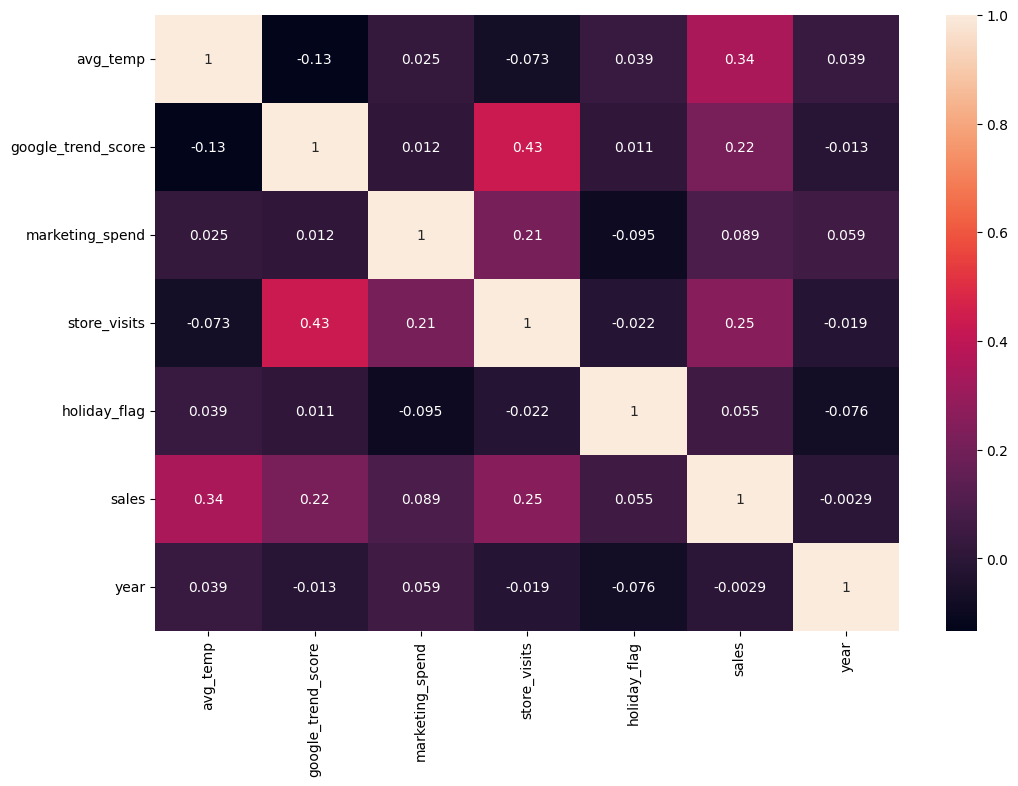

In [30]:
correlation = df_copy.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(correlation,annot=True)

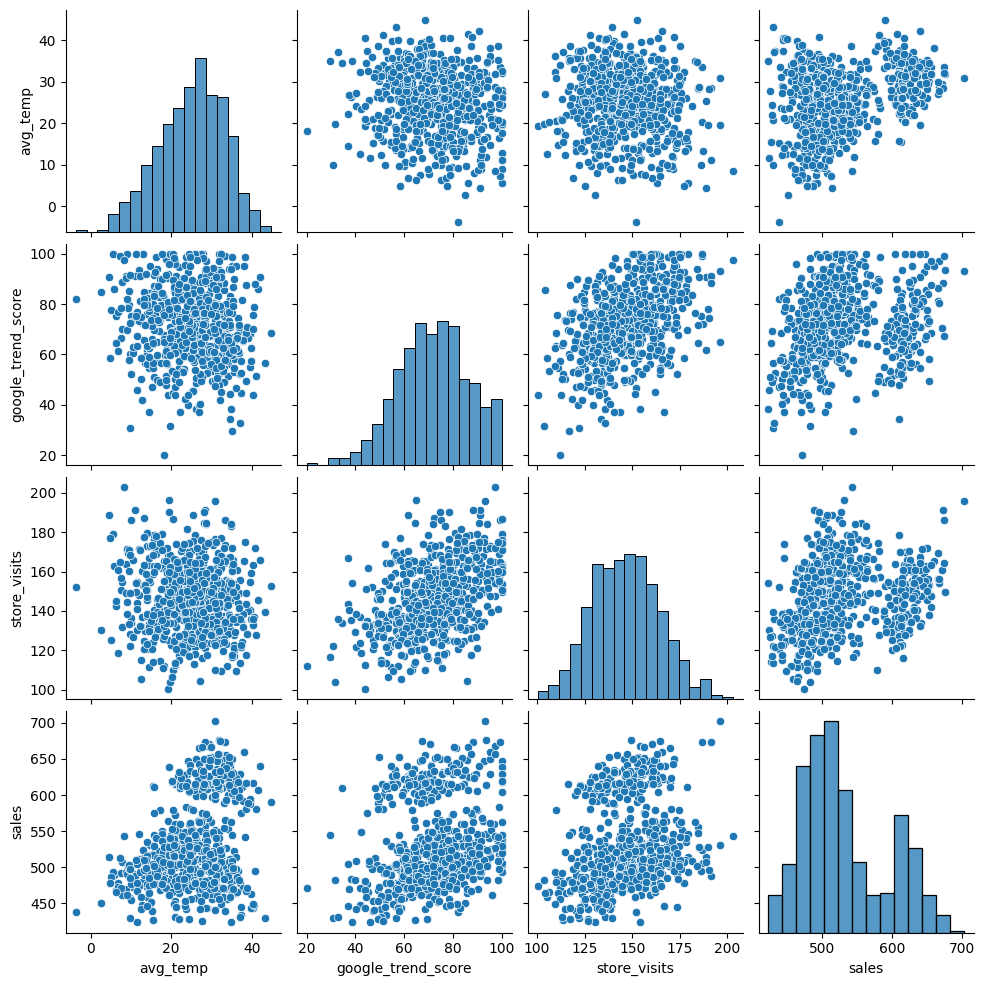

In [31]:
col = ["avg_temp","google_trend_score","store_visits","sales"]
sns.pairplot(
    df[col],
    diag_kind="hist"
)
plt.show()

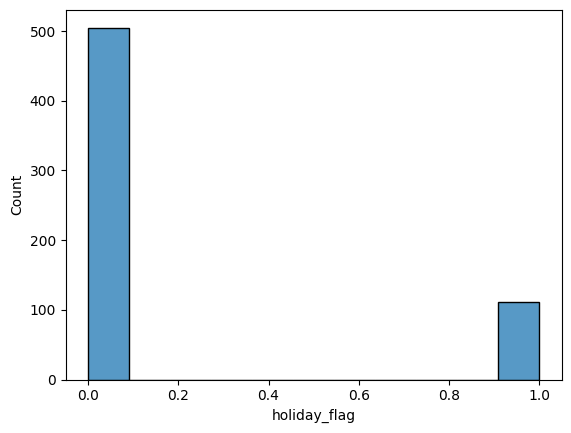

In [32]:
sns.histplot(df_copy['holiday_flag'])
plt.show()

In [33]:
df_copy = df_copy.drop(["year","month","quarter"],axis =1)

## Feature Engineering

In [34]:
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureEngineer(BaseEstimator, TransformerMixin):

    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        X = X.copy()


        # Date Features

        X["week_start"] = pd.to_datetime(
            X["week_start"],
            dayfirst=True
        )

        X["year"] = X["week_start"].dt.year
        X["month"] = X["week_start"].dt.month
        X["quarter_num"] = X["week_start"].dt.quarter
        X["week_no"] = X["week_start"].dt.isocalendar().week.astype(int)


        # Interaction Features


        # Marketing × Google Trend
        X["marketing_x_trend"] = (
            X["marketing_spend"] *
            X["google_trend_score"]
        )

        # Marketing × Store Visits
        X["marketing_x_visits"] = (
            X["marketing_spend"] *
            X["store_visits"]
        )

        # Holiday Marketing
        X["marketing_holiday"] = (
            X["marketing_spend"] *
            X["holiday_flag"]
        )

        # Ratio Feature

        X["visit_trend_ratio"] = (
            X["store_visits"] /
            (X["google_trend_score"] + 1)
        )

        return X

In [35]:
# X.columns

# Defining Feature and Target

In [36]:
x = df_copy.drop(axis=1,columns=['sales'])
y = df_copy['sales']

In [37]:
x

,week_start,region,avg_temp,google_trend_score,marketing_spend,store_visits,holiday_flag
0,2022-01-02,North,16.148359,77.731496,59.477217,171.287943,0
1,2022-01-09,North,13.498203,56.721545,42.961597,129.713810,0
2,2022-01-16,North,20.155553,63.583106,41.756808,138.380782,1
3,2022-01-23,North,18.852930,47.855055,83.285668,140.217833,1
4,2022-01-30,North,16.324140,98.691569,14.112839,168.959707,0
...,...,...,...,...,...,...,...
623,2024-12-01,West,31.000074,47.662804,47.235254,122.493353,1
624,2024-12-08,West,35.341897,79.061813,92.526726,135.844589,0
625,2024-12-15,West,30.994748,79.742460,40.328455,143.787383,0
626,2024-12-22,West,40.249060,70.010242,64.437233,136.029077,0


# Data Preprocessing Using Pipeline

In [38]:
numercial_feature = ['avg_temp','google_trend_score','marketing_spend','store_visits','holiday_flag']
categorical_feature = x.select_dtypes(include="object").columns

In [39]:
numeric_tranformer = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')),
        ('StandardScaler',StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('Ordinal',OrdinalEncoder())
    ]
)

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric',numeric_tranformer,numercial_feature),
        ('categorical',categorical_transformer,categorical_feature)
    ]
)

# Train Test Split

In [41]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.75,random_state=42)

# Regression Models

In [42]:
linear_model = Pipeline(
    steps = [
        ('featureEngineering',FeatureEngineer()),
        ('preprocessor',preprocessor),
        ('linear model',LinearRegression())
    ]
)

In [43]:
polyLR_model = Pipeline(
    steps = [
        ('featureEngineering',FeatureEngineer()),
        ('preprocessor',preprocessor),
        ('poly feature',PolynomialFeatures(degree=3,include_bias=False)),
        ('linear model',LinearRegression())
    ]
)

In [44]:
ridge_model = Pipeline(
    steps = [
        ('featureEngineering',FeatureEngineer()),
        ('preprocessor',preprocessor),
        ('ridge model',Ridge(alpha=5))
    ]
)

In [45]:
lasso_model = Pipeline(
    steps = [
        ('featureEngineering',FeatureEngineer()),
        ('preprocessor',preprocessor),
        ('Lasso model',Lasso(alpha=5))
    ]
)

In [46]:
ElasticNet_model = Pipeline(
    steps = [
        ('featureEngineering',FeatureEngineer()),
        ('preprocessor',preprocessor),
        ('Lasso model',ElasticNet(alpha=5))
    ]
)

In [47]:
KNNRegressor_model = Pipeline(
    steps = [
        ('featureEngineering',FeatureEngineer()),
        ('preprocessor',preprocessor),
        ('KNNRegressor model',KNeighborsRegressor(n_neighbors=3))
    ]
)

In [48]:
models = {
    'linear_model':linear_model,
    'polyLR_model':polyLR_model,
    'ridge_model':ridge_model,
    'lasso_model':lasso_model,
    'ElasticNet_model':ElasticNet_model,
    'KNNRegressor_model':KNNRegressor_model
}
n = x_test.shape[0]
p = x_test.shape[1]

for name , model in models.items():
  model.fit(x_train,y_train)
  y_pred = model.predict(x_test)

  print(f'{name}')
  print("*********************")
  print('Metric Evaluation')
  mae = mean_absolute_error(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_test, y_pred)

  adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

  print("MAE:", mae)
  print("MSE:", mse)
  print("RMSE:", rmse)
  print("R²:", r2)
  print("Adjusted R²:", adj_r2)



  print('\n')

linear_model
*********************
Metric Evaluation
MAE: 42.2807201988628
MSE: 2932.9426306025607
RMSE: 54.15664899716895
R²: 0.2217987531587362
Adjusted R²: 0.18474155092819988


polyLR_model
*********************
Metric Evaluation
MAE: 14.951613952664564
MSE: 358.95313974862194
RMSE: 18.94605868640288
R²: 0.9047585254497204
Adjusted R²: 0.9002232171378023


ridge_model
*********************
Metric Evaluation
MAE: 42.275741345405244
MSE: 2931.2881224161497
RMSE: 54.14137163404848
R²: 0.22223774583460376
Adjusted R²: 0.18520144801720395


lasso_model
*********************
Metric Evaluation
MAE: 43.67382516621983
MSE: 3072.2334086181227
RMSE: 55.427731404217894
R²: 0.18484056107063163
Adjusted R²: 0.14602344493113784


ElasticNet_model
*********************
Metric Evaluation
MAE: 47.64473646966123
MSE: 3482.5041661202636
RMSE: 59.012745793771224
R²: 0.07598292038603272
Adjusted R²: 0.031982107071081844


KNNRegressor_model
*********************
Metric Evaluation
MAE: 25.543359650018864

In [51]:
polyLR_model.fit(x_train,y_train)

Pipeline(steps=[('featureEngineering', FeatureEngineer()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('StandardScaler',
                                                                   StandardScaler())]),
                                                  ['avg_temp',
                                                   'google_trend_score',
                                                   'marketing_spend',
                                                   'store_visits',
                                                   'holiday_flag']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Ordinal',
                                                                   OrdinalEncoder())]),
                                                  Index(['region'], dtype='object'))])),
                ('poly feature',
                 PolynomialFeatures(degree=3, include_bias=False)),
                ('linear model', LinearRegression())])

In [52]:
joblib.dump(polyLR_model,'/content/drive/MyDrive/ML Project/polyLR.pkl')

['/content/drive/MyDrive/ML Project/polyLR.pkl']